<a href="https://colab.research.google.com/github/cermegno/llm-evals/blob/main/04-deepeval-rag-evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepEval Single-Turn evaluation


In [3]:
!pip install deepeval langchain langchain-nvidia-ai-endpoints langchain-core --quiet

In [4]:
import os
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_core.prompts import ChatPromptTemplate
import json

## Nvidia setup

In [5]:
# Initialize the LLM
from google.colab import userdata
apikey = userdata.get('apikey')
os.environ["NVIDIA_API_KEY"] = apikey
#JUDGE model  ChatNVIDIA(model="openai/gpt-oss-120b")

We need to wrap the Nvidia model.

**IMPORTANT**. Need to use a model that is capable of returning strictly JSON when requested. The Mistral small did the trick

In [19]:
from deepeval.models import DeepEvalBaseLLM

class CustomNvidiaLLM(DeepEvalBaseLLM):
    #model_name = "openai/gpt-oss-120b"
    #model_name = "nvidia/nemotron-3-nano-30b-a3b"
    model_name = "mistralai/mistral-small-4-119b-2603"

    def __init__(self):
        os.environ["NVIDIA_API_KEY"] = os.environ.get("NVIDIA_API_KEY", "")
        self.model = ChatNVIDIA(model=self.model_name)

    def load_model(self):
        return self.model

    def generate(self, prompt: str) -> str:
        model = self.load_model()
        # DeepEval expects a plain string back
        return model.invoke(prompt).content

    async def a_generate(self, prompt: str) -> str:
        model = self.load_model()
        res = await model.ainvoke(prompt)
        return res.content

    def get_model_name(self):
        return self.model_name

nvidia_judge = CustomNvidiaLLM()

## Create Dataset
I got this question, context and answer from another project using these models from Nvidia's public api endpoints:
 - embedding model: nvidia/nv-embed-v1
 - LLM: meta/llama-3.1-8b-instruct

 I got the 'expected output' from Gemini

In [7]:
#!! Using a single LLMTestCase avoid hitting RPM throttling from Nvidia endpoints
input = "Why rockets fly"

actual_output = """Rockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction. This principle is the fundamental reason behind the flight of rockets.

Here's a step-by-step explanation:

1. **Propulsion**: Inside the rocket, a fuel and an oxidizer are mixed together and burned in a combustion chamber, producing hot, high-pressure gas.
2. **Movement in Space**: Unlike airplanes, which need air to push against, rockets operate in the vacuum of space. This absence of air resistance actually makes rockets more efficient.
3. **Overcoming Gravity**: To launch from Earth, a rocket's thrust must be greater than the force of gravity pulling it down. This is achieved by expelling the hot gas produced in the combustion chamber at extremely high speeds.
4. **Thrust**: As the hot gas is expelled out of the rocket's nozzle, it creates an action that results in an equal and opposite reaction. This reaction is what propels the rocket forward, creating the force known as thrust.
5. **Momentum**: The momentum of the expelled gas is equal to the momentum gained by the rocket, propelling it in the opposite direction. This momentum is what gives the rocket its speed and allows it to overcome the force of gravity and fly into space.

In summary, rockets fly because of the action-reaction principle, where the expulsion of hot gas creates an equal and opposite reaction that propels the rocket forward, generating thrust and momentum that allows it to overcome gravity and reach space.
"""

retrieval_context = [
        """Introduction to Rocketry\n------------------------\nRockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction.\nHere's how it works:\n- Propulsion: Rockets carry their own fuel and an oxidizer. This mixture is burned in a combustion chamber, producing hot, high-pressure gas."""
        """- Movement in Space: Unlike airplanes, rockets don't need air to push against. They operate on the principle of action and reaction. In the vacuum of space, the absence of air resistance actually makes rockets more efficient.\n- Overcoming Gravity: To launch from Earth, a rocket's thrust must be greater than the force of gravity pulling it down."""
        """- Thrust: This gas is forced out of the rocket's nozzle at extremely high speeds. The action of the gas being expelled creates an equal and opposite reaction, pushing the rocket forward. This force is called thrust.\n- Momentum: The momentum of the expelled gas is equal to the momentum gained by the rocket, propelling it in the opposite direction."""
    ]

expected_output = """
Rockets fly because of Newton’s Third Law of Motion: every action has an equal and opposite reaction.Inside a rocket engine, fuel and an oxidizer mix and burn in a combustion chamber. This chemical reaction creates intensely hot, high-pressure gas. The engine forces this gas downward through a narrow nozzle at supersonic speeds. As the engine expels this exhaust gas backward (the action), the gas pushes the rocket forward (the reaction). This upward force is called thrust.
Rockets do not need to push against the air or the ground to move. Instead, they push against their own escaping exhaust mass. This means rockets work perfectly in the vacuum of space. Because space has no air, airplanes cannot fly there. Airplanes need atmospheric oxygen to burn fuel and wings to create lift. Rockets solve this problem by carrying their own oxygen supply in specialized oxidizer tanks.
When a rocket launches, it initially flies straight up. This vertical path helps it exit the thickest parts of Earth's atmosphere as quickly as possible, minimizing air resistance. Soon after, the rocket tilts into a horizontal arc. Reaching space is only the first step; staying there requires extreme horizontal speed. To achieve orbit, a spacecraft must travel sideways at roughly 17,500 mph (28,000 km/h). At this speed, the rocket continuously falls toward Earth, but the planet curves away beneath it at the exact same rate, keeping the vehicle in a permanent state of freefall.
"""



## Set up Deepeval


In [8]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase
from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualRecallMetric,
    ContextualPrecisionMetric
)

Define test case from our dataset

In [9]:
# test_cases = [
#     LLMTestCase(
#         input=q,
#         actual_output=a,          # model answer
#         # no context, no expected_output
#     )
#     for q, a in zip(questions, answers)
# ]

test_case = LLMTestCase(
    input = input,
    actual_output = actual_output,
    retrieval_context = retrieval_context,
    expected_output = expected_output
)

###Setup RAG metrics

In [20]:
faithfulness = FaithfulnessMetric(threshold=0.7, model=nvidia_judge)
answer_relevancy = AnswerRelevancyMetric(threshold=0.7, model=nvidia_judge)
context_recall = ContextualRecallMetric(threshold=0.7, model=nvidia_judge)
context_precision = ContextualPrecisionMetric(threshold=0.7, model=nvidia_judge)

metrics = [faithfulness, answer_relevancy, context_recall, context_precision]

## Evaluate

In [ ]:
results = evaluate(test_cases=[test_case], metrics=metrics)

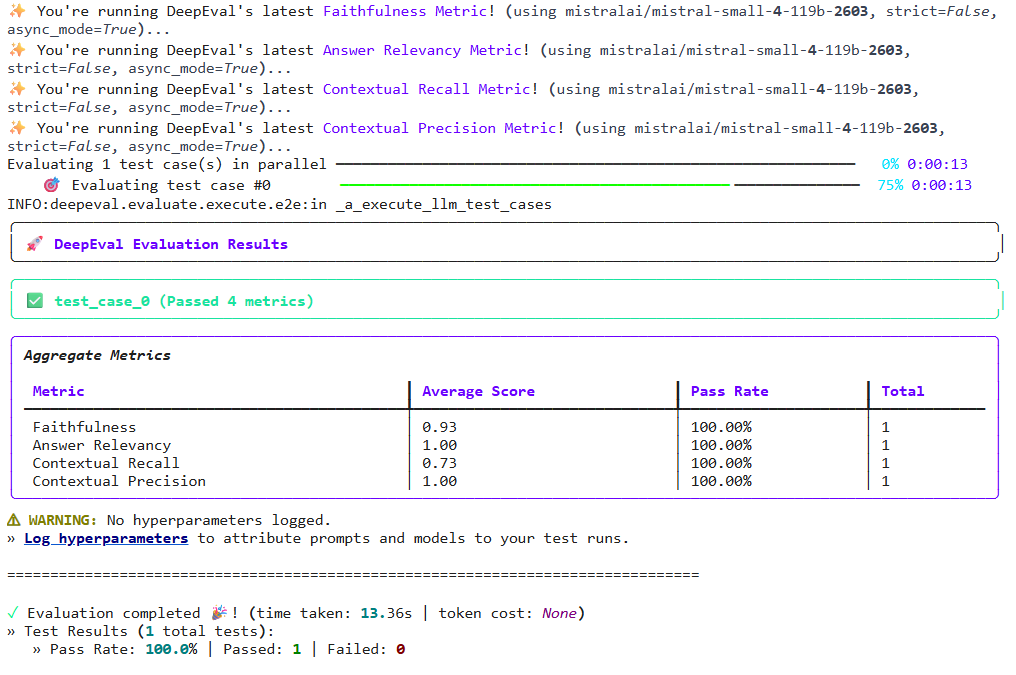

In [22]:
from pprint import pprint
pprint(results.test_results)

[TestResult(name='test_case_0',
            success=True,
            metrics_data=[MetricData(name='Faithfulness', threshold=0.7, success=True, score=0.9333333333333333, reason="The score is 0.93 because the only contradiction is a minor misstatement about direct comparison to airplanes, which does not significantly deviate from the retrieval context's meaning.", strict_mode=False, evaluation_model='mistralai/mistral-small-4-119b-2603', error=None, evaluation_cost=None, verbose_logs='Truths (limit=None):\n[\n    "Rockets fly based on Newton\'s third law of motion.",\n    "Newton\'s third law states that for every action, there is an equal and opposite reaction.",\n    "Rockets carry their own fuel and an oxidizer.",\n    "The rocket\'s fuel and oxidizer mixture is burned in a combustion chamber.",\n    "Burning the fuel and oxidizer mixture produces hot, high-pressure gas.",\n    "Rockets do not need air to push against to operate.",\n    "Rockets operate on the principle of action an

In [23]:
for i, tr in enumerate(results.test_results):
    print(f"\nTest case {i+1}: {tr.input}")
    for md in tr.metrics_data:
        print(f"  Metric: {md.name}")
        print(f"  Score:  {md.score}")
        print(f"  Passed: {md.success}")
        print(f"  Reason: {md.reason}")


Test case 1: Why rockets fly
  Metric: Faithfulness
  Score:  0.9333333333333333
  Passed: True
  Reason: The score is 0.93 because the only contradiction is a minor misstatement about direct comparison to airplanes, which does not significantly deviate from the retrieval context's meaning.
  Metric: Answer Relevancy
  Score:  1.0
  Passed: True
  Reason: The score is 1.00 because the actual output directly and fully addresses the input with no irrelevant statements.
  Metric: Contextual Recall
  Score:  0.7272727272727273
  Passed: True
  Reason: The score is 0.73 because most of the expected output's sentences (1-6) align closely with details in the 1st node of the retrieval context, particularly regarding Newton’s Third Law, propulsion, thrust, and movement principles. However, the later sentences (7-9) introduce unsupported new information about flight trajectory and orbital mechanics absent from the retrieval context.
  Metric: Contextual Precision
  Score:  1.0
  Passed: True
  